## Cholorophyll plotting

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [3]:
from scipy import stats

In [4]:
from functions import preproc_funcs as funcs

In [5]:
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
# import mpatches
import matplotlib.patches as mpatches


In [7]:
import regionmask

In [8]:
def plot_background(ax, draw_labels=False, draw_ipcc_regions=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    if draw_ipcc_regions:
        ar6_reg = regionmask.defined_regions.ar6.all

        # Plot the region boundaries, passing the same 'ax'
        # Use 'line_kws' to customize line properties (color, thickness, etc.)
        ar6_reg.plot_regions(
            ax=ax,
            line_kws=dict(color='black', lw=1.0, alpha=0.4),
            text_kws=dict(fontsize=8, color='k'), # Set to True to add text labels for regions
            add_label=False, # Set to True to add text labels for regions
        )
    return ax




def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), invert_proj = False,
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_not_equal(pval[i], 0)
                if invert_proj:
                    axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='///', transform = ccrs.PlateCarree(central_longitude=180))
                else:
                    axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='///', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] > 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_not_equal(pval[i], 1)
                if invert_proj:
                    axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=180))
                else:
                    axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] <= 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.01, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return axlist



def plot_single_map(x, y, z, title, label, cmap, levels, add_sign=False, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), invert_proj = False,
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if add_sign:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            if invert_proj:
                ax.pcolor(x, y, pval_plot, alpha = 0., hatch='//', transform = ccrs.PlateCarree(central_longitude=180))
            else:
                ax.pcolor(x, y, pval_plot, alpha = 0., hatch='//', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval > 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            if invert_proj:
                ax.pcolor(x, y, pval_plot, alpha = 0., hatch='..', transform = ccrs.PlateCarree(central_longitude=180))
            else:
                ax.pcolor(x, y, pval_plot, alpha = 0., hatch='..', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval <= 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.01, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return ax

In [9]:
import cmocean

### load data

In [10]:
chl_raw = xc.open_dataset('./data/CHLOR-A_mon_obs4MIPS_SeaWiFS-MODIS-MERIS-VIIRS-OLCI_L3S_fv6.0_0.5deg_19970901-20220630.nc', lon_orient=(-180, 180))
chl_raw

<xarray.Dataset> Size: 1GB
Dimensions:             (time: 298, lat: 360, lon: 720, bound_levels: 2, olev: 1)
Coordinates:
  * lat                 (lat) float64 3kB 89.75 89.25 88.75 ... -89.25 -89.75
  * olev                (olev) float64 8B 0.0
  * time                (time) object 2kB 1997-09-18 12:00:00 ... 2022-06-15 ...
  * lon                 (lon) float64 6kB -179.8 -179.2 -178.8 ... 179.2 179.8
Dimensions without coordinates: bound_levels
Data variables:
    chlor_a             (time, lat, lon) float64 618MB ...
    chlor_a_log10_bias  (time, lat, lon) float32 309MB ...
    chlor_a_log10_rmsd  (time, lat, lon) float32 309MB ...
    lat_bounds          (lat, bound_levels) float64 6kB ...
    lon_bounds          (lon, bound_levels) float64 12kB 0.0 0.49 ... -0.5 -0.01
    time_bounds         (time, bound_levels) object 5kB ...
Attributes: (12/22)
    nominal_resolution:   24 km
    frequency:            mon
    grid:                 0.5x0.5 degree latitude x longitude
    grid_label:           gn
    Conventions:          CF-1.7 ODS-2.1
    source_type:          satellite_retrieval
    ...                   ...
    time_coverage_start:  199709040000Z
    time_coverage_end:    202206302359Z
    stop_date:            30-Jun-2022 23:59:59.000000
    history:              Wed Aug 31 12:26:25 2022: ncatted -O -a stop_date,g...
    NCO:                  netCDF Operators version 4.7.5 (Homepage = http://n...
    id:                   CHLOR-A_mon_obs4MIPS_SeaWiFS-MODIS-MERIS-VIIRS-OLCI...

In [11]:
chl_clean = chl_raw.where((chl_raw.chlor_a > 0) & (chl_raw.chlor_a < 1e-2))

In [12]:
chl_clean.chlor_a

<xarray.DataArray 'chlor_a' (time: 298, lat: 360, lon: 720)> Size: 618MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) object 2kB 1997-09-18 12:00:00 ... 2022-06-15 12:00:00
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    units:                kilogram m-3
    units_nonstandard:    kg m^-3
    coordinate:           lat-lon

In [13]:
chl_clean_mg = chl_clean.chlor_a * 1e6

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

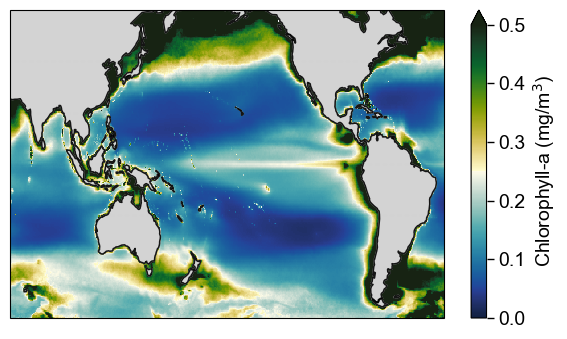

In [14]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
chl_clean_mg.sel(lat = slice(60, -60), lon = slice(60-180, 330-180)).mean('time').plot(cmap=cmocean.cm.delta, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=0, vmax=0.5, cbar_kwargs={'label': 'Chlorophyll-a (mg/m$^3$)'})
ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
plot_background(ax)


In [15]:
chl_lognorm = np.log10(chl_clean_mg)

In [16]:
chl_a_sondjf = chl_clean_mg.sel(time = chl_clean_mg.time.dt.month.isin([9,10,11,12,1,2])).resample(time='AS-JUN').mean(dim='time')#.isel(time = slice(3, None))
chl_a_sondjf

<xarray.DataArray 'chlor_a' (time: 25, lat: 360, lon: 720)> Size: 52MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * time     (time) object 200B 1997-06-01 00:00:00 ... 2021-06-01 00:00:00

In [17]:
mixed_years = np.array([1908,1910,1916,1917,1922,1949,1995])
cp_years = np.array([1903,1909,1924,1933,1938,1942,1950,1954,1955,1964,1970,1971,1973,1974,1975,1984,1988,1998,1999,2000,2007,2010,2011,2020,2022])
ep_years = np.array([1906,1962,1967,2017,2021])
neut_years = np.array([1901,1907,1912,1921,1923,1926,1927,1928,1929,1931,1932,1934,1935,1936,1943,1944,1945,1946,1947,1948,1952,1953,1958,1959,1960,1978,1980,1981,1983,1989,1990,1993,1996,2001,2008,2012,2013,2016,2019])
en_years = np.array([1987, 1991, 1993, 1994, 1997, 2002, 2006, 2009, 2015, 2023])

In [18]:
chl_a_neut = chl_a_sondjf.sel(time = chl_a_sondjf.time.dt.year.isin([neut_years]))
chl_a_cp = chl_a_sondjf.sel(time = chl_a_sondjf.time.dt.year.isin([cp_years]))
chl_a_ep = chl_a_sondjf.sel(time = chl_a_sondjf.time.dt.year.isin([ep_years]))
chl_a_en = chl_a_sondjf.sel(time = chl_a_sondjf.time.dt.year.isin([en_years]))

In [19]:
def plot_background(ax, draw=True):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    ax.add_feature(cfeature.LAND, color='k', alpha=0.9, zorder=1)
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

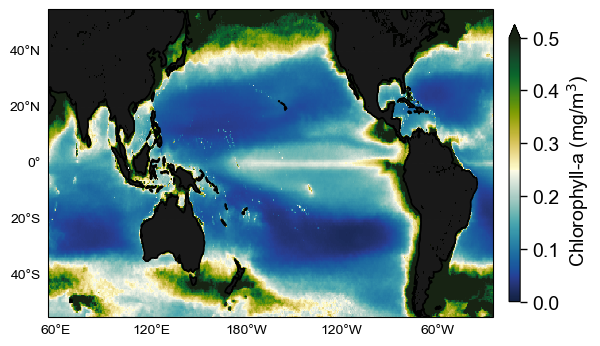

In [20]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=160))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
chl_a_neut.sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).mean('time').plot(cmap=cmocean.cm.delta, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=0, vmax=0.5, cbar_kwargs={'label': 'Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(0, 0.6, 0.1)})
plot_background(ax)

In [21]:
# fig = plt.figure(figsize=(7, 4))
# ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=160))
# ax.set_aspect('auto')
# # test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
# (chl_a_en.mean('time') - chl_a_neut.mean('time')).sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).plot(cmap=cmocean.cm.tarn, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=-0.1, vmax=0.1, cbar_kwargs={'label': '$\Delta$ Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(-0.1, 0.14, 0.04)})
# plot_background(ax)

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

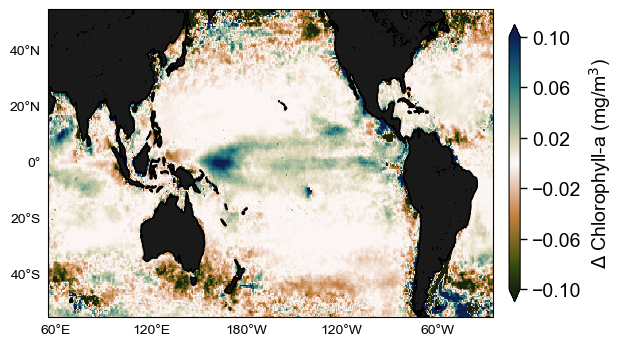

In [22]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=160))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
(chl_a_cp.mean('time') - chl_a_neut.mean('time')).sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).plot(cmap=cmocean.cm.tarn, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=-0.1, vmax=0.1, cbar_kwargs={'label': '$\Delta$ Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(-0.1, 0.14, 0.04)})
plot_background(ax)

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

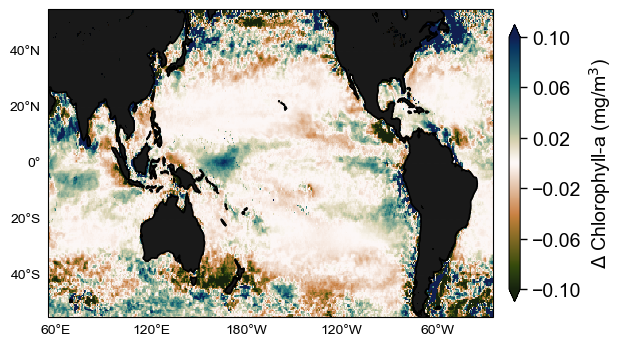

In [23]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
(chl_a_ep.mean('time') - chl_a_neut.mean('time')).sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).plot(cmap=cmocean.cm.tarn, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=-0.1, vmax=0.1, cbar_kwargs={'label': '$\Delta$ Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(-0.1, 0.14, 0.04)})
plot_background(ax)

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

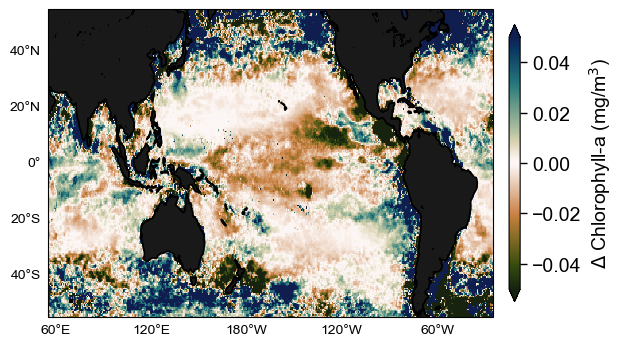

In [24]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
(chl_a_ep.mean('time') - chl_a_cp.mean('time')).sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).plot(cmap=cmocean.cm.tarn, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=-0.05, vmax=0.05, cbar_kwargs={'label': '$\Delta$ Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(-0.06, 0.08, 0.02)})
plot_background(ax)

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

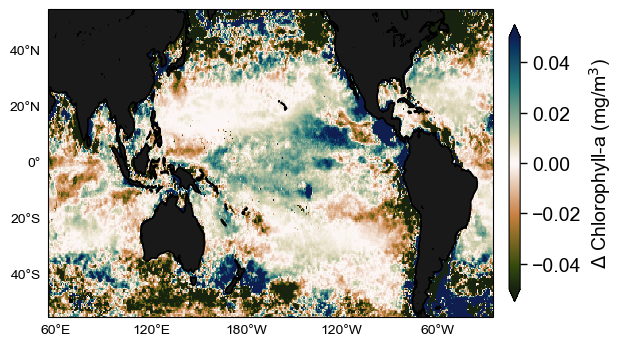

In [25]:
fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
# test.where(test < 100).mean('time').plot(cmap=cmocean.cm.deep , robust=True, transform=ccrs.PlateCarree())
(chl_a_cp.mean('time') - chl_a_ep.mean('time')).sel(lat = slice(55, -55), lon = slice(55-180, 335-180)).plot(cmap=cmocean.cm.tarn, robust=True, transform=ccrs.PlateCarree(central_longitude=180), vmin=-0.05, vmax=0.05, cbar_kwargs={'label': '$\Delta$ Chlorophyll-a (mg/m$^3$)', 'aspect': 25, 'pad': 0.03, 'shrink': 0.9, 'ticks': np.arange(-0.06, 0.08, 0.02)})
plot_background(ax)

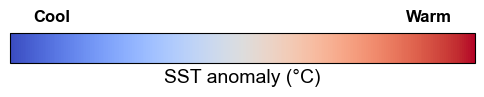

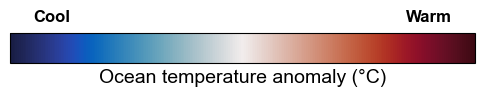